In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)


# CLASSIFICATION

# 1.1 Logistic Regression for Credit Default Prediction

In [ ]:
# 1. Load Data
df = pd.read_csv('cs-training.csv').drop(columns=['Unnamed: 0'], errors='ignore')

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

In [ ]:
# 2. Pre-processing
# (a) Median Imputation
X['MonthlyIncome'] = X['MonthlyIncome'].fillna(X['MonthlyIncome'].median())
X['NumberOfDependents'] = X['NumberOfDependents'].fillna(X['NumberOfDependents'].median())

# (b) Stratified 70/15/15 Split
# First split out the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
# Split the remaining 85% into train (70% of total) and validation (15% of total)
# 0.15 / 0.85 approx 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15 / 0.85), stratify=y_train_val, random_state=42
)

# (c) Standardise features using scaler fitted ONLY on the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 3.Train Logistic Regression Model
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on Test Set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_prob)
}

metrics_df = pd.DataFrame(metrics, index=['Test Set Metrics']).round(4)
print(metrics_df)

In [ ]:
# 4. Plot ROC and Confusion Matrix side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {metrics["AUC-ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic (ROC)')
ax[0].legend(loc="lower right")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap=plt.cm.Reds, ax=ax[1], values_format='d')
ax[1].set_title('Confusion Matrix ($\tau = 0.5$)')

plt.tight_layout()
plt.show()

In [ ]:
# 5. Vary Classification Threshold
thresholds = np.arange(0.1, 1.0, 0.1)
precisions = []
recalls = []
f1_scores = []

# Using validation set to find the optimal threshold (standard practice before test confirmation)
y_prob_val = model.predict_proba(X_val_scaled)[:, 1]

for tau in thresholds:
    y_pred_tau = (y_prob_val >= tau).astype(int)
    precisions.append(precision_score(y_val, y_pred_tau, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_tau))
    f1_scores.append(f1_score(y_val, y_pred_tau, zero_division=0))

best_idx = np.argmax(f1_scores)
best_tau = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Plot Precision & Recall vs Threshold
plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label='Precision', marker='o', color='teal')
plt.plot(thresholds, recalls, label='Recall', marker='s', color='crimson')
plt.plot(thresholds, f1_scores, label='F1-Score', linestyle='--', color='gold', alpha=0.7)
plt.axvline(best_tau, color='black', linestyle=':', label=f'Max $F_1$ Threshold ($\tau={best_tau:.1f}$)')

plt.xlabel('Classification Threshold ($\\tau$)')
plt.ylabel('Metric Score')
plt.title('Precision & Recall vs. Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"The threshold that maximises F1-Score on validation set is: {best_tau:.1f} (F1 = {best_f1:.4f})")

In [ ]:
# 6. Examine the trained coefficient vector w
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
}).sort_values(by='Absolute_Coefficient', ascending=False)

print("\nTop 5 Features by |w_j|:")
print(feature_importance.head(5).to_string(index=False))

The resulting magnitudes of $\hat{w}_j$ directly reflect feature importance regardless of original units. A positive coefficient implies that an increase in that feature raises the log-odds (and thus the probability) of a borrower experiencing serious financial distress within two years. Typically, variables representing past payment delinquencies (e.g., NumberOfTime30-59DaysPastDueNotWorse) yield the largest positive coefficients, illustrating that historical payment behavior is a powerful predictor of future credit default risks. Conversely, features measuring assets or stable ratios will often exhibit inverse relationships.

# 1.2 Decision Tree Classifier with Pruning for Heart Disease

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Load Dataset
df = pd.read_csv('heart_disease_uci.csv')
# Process Target Variable: Map raw 'num' integer values (0 to 4) into a binary classification target (0 or 1)
df['target'] = (df['num'] > 0).astype(int)

# Separate features and target, discarding the raw 'num' and 'id' columns
X = df.drop(columns=['num', 'target', 'id'], errors='ignore')
y = df['target']

#Encode Categorical Columns
# Identifies columns with text/strings and automatically converts them to binary flags
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [ ]:
# 2. Stratified 70/15/15 Split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15 / 0.85), stratify=y_train_val, random_state=42
)

In [ ]:

# 3. Train Unpruned Tree
unpruned_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
unpruned_tree.fit(X_train, y_train)

train_acc_unpruned = accuracy_score(y_train, unpruned_tree.predict(X_train))
test_acc_unpruned = accuracy_score(y_test, unpruned_tree.predict(X_test))

print(f"Unpruned Tree -> Train Accuracy: {train_acc_unpruned*100:.2f} % | Test Accuracy: {test_acc_unpruned*100:.2f} %")

In [ ]:
# 4. Train with depth limits
depths = [1, 2, 3, 5, 7, 10, 15, None]
depth_labels = [str(d) for d in depths]
train_scores = []
val_scores = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    val_scores.append(accuracy_score(y_val, clf.predict(X_val)))

# Plot Depth vs Accuracy
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_scores, marker='o', label='Train Accuracy', color='blue')
plt.plot(depth_labels, val_scores, marker='s', label='Validation Accuracy', color='orange')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Depth vs. Accuracy Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find depth maximizing validation accuracy
best_depth_idx = np.argmax(val_scores)
best_depth = depths[best_depth_idx]
print(f"Best max_depth based on validation score: {best_depth}")

In [ ]:
# 5. Retrain best depth-limited tree on Train + Validation combined
X_train_val_combined = pd.concat([X_train, X_val])
y_train_val_combined = pd.concat([y_train, y_val])

best_depth_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_depth_tree.fit(X_train_val_combined, y_train_val_combined)

depth_test_auc = roc_auc_score(y_test, best_depth_tree.predict_proba(X_test)[:, 1])
depth_test_f1 = f1_score(y_test, best_depth_tree.predict(X_test))

In [ ]:
# 6. Minimal Cost-Complexity Pruning
# (a) Get effective alphas sequence from the training set using the unpruned structure
path = unpruned_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the last alpha because it trims the entire tree into a single root node leaf
ccp_alphas = ccp_alphas[:-1]

# (b) Train a tree for each alpha and track validation AUC-ROC
alpha_val_aucs = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    val_auc = roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])
    alpha_val_aucs.append(val_auc)

# (c) Select the optimal alpha*
best_alpha_idx = np.argmax(alpha_val_aucs)
best_alpha = ccp_alphas[best_alpha_idx]
print(f"Optimal alpha* that maximizes validation AUC-ROC: {best_alpha:.6f}")

# Retrain the optimal ccp tree on Train + Validation combined
best_ccp_tree = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
best_ccp_tree.fit(X_train_val_combined, y_train_val_combined)

ccp_test_auc = roc_auc_score(y_test, best_ccp_tree.predict_proba(X_test)[:, 1])
ccp_test_f1 = f1_score(y_test, best_ccp_tree.predict(X_test))

In [ ]:
from sklearn.tree import plot_tree
# 7. Visualise the final pruned tree (up to 4 levels) using updated encoded feature names
plt.figure(figsize=(18, 10))
plot_tree(
    best_ccp_tree,
    max_depth=4,
    feature_names=list(X.columns),  # Converted to list to ensure clean matching with dummy columns
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title(f"Final Pruned Tree Structure (CCP Alpha = {best_alpha:.5f})", fontsize=14)
plt.show()

# Generate the final comparison table
summary_data = {
    "Model Variant": ["Unpruned Tree", f"Depth-Limited (max_depth={best_depth})", f"Cost-Complexity Pruned ($\\alpha$={best_alpha:.4f})"],
    "Test AUC-ROC": [roc_auc_score(y_test, unpruned_tree.predict_proba(X_test)[:, 1]), depth_test_auc, ccp_test_auc],
    "Test F1": [f1_score(y_test, unpruned_tree.predict(X_test)), depth_test_f1, ccp_test_f1],
    "Tree Depth": [unpruned_tree.get_depth(), best_depth_tree.get_depth(), best_ccp_tree.get_depth()]
}

summary_df = pd.DataFrame(summary_data).round(4)
print("\n=== Deliverable Comparison Table ===")
print(summary_df.to_string(index=False))

8. Cost-Complexity Pruning (CCP) typically yields a higher or equivalent Test AUC-ROC compared to strict depth-limiting while often revealing a structural depth that doesn't strictly match standard integer thresholds. This happens because CCP mitigates the "horizon effect" by evaluating branches globally after full growth rather than stopping early based on immediate, myopic feature split metrics. Consequently, it retains deeply nested, informative multi-variable splits while removing noisy leaf nodes that cause overfitting.

# REGRESSION

# 2.1 Regularised Regression for House Price Prediction

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import Lasso

# 1. Load Data
df = pd.read_csv('AmesHousing.csv').drop(columns=['Id'], errors='ignore')

In [ ]:
# 2. Pre-processing
# (a) Log-transform target
df['SalePrice'] = np.log1p(df['SalePrice'])

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# (b) Drop features with > 40% missing values
missing_pct = X.isnull().mean()
X = X.loc[:, missing_pct <= 0.40]

# Split into Train/Val/Test (70/15/15) to maintain consistency with previous setups
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=(0.15 / 0.85), random_state=42
)

# Avoid data leakage: compute statistics on X_train only
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns

# (c) Impute missing values
for col in numeric_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in categorical_cols:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_val[col] = X_val[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# (d) One-Hot Encode Categorical Features
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns to handle missing categories across splits
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# (e) Standardise all numeric features (fitted ONLY on training)
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
# Setup log scale grids for regularisation strengths (alpha in sklearn)
alphas_grid = np.logspace(-3, 3, 50)
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]

# Baseline OLS for comparison table
ols = LinearRegression().fit(X_train, y_train)

# 3. Train Regularised Models via 5-fold CV
ridge_cv = RidgeCV(alphas=alphas_grid, cv=5).fit(X_train, y_train)
lasso_cv = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000, random_state=42).fit(X_train, y_train)
elastic_cv = ElasticNetCV(alphas=alphas_grid, l1_ratio=l1_ratios, cv=5, max_iter=10000, random_state=42).fit(X_train, y_train)

models = {"OLS": ols, "Ridge": ridge_cv, "Lasso": lasso_cv, "Elastic Net": elastic_cv}
summary_rows = []

In [ ]:
# 4. Evaluate Metrics (Back-transforming via exp(y)-1)
for name, model in models.items():
    pred_log = model.predict(X_test)
    pred_back = np.expm1(pred_log)
    y_test_back = np.expm1(y_test)

    rmse = root_mean_squared_error(y_test_back, pred_back)
    r2 = r2_score(y_test, pred_log) # R2 traditionally calculated on the modeled scale

    # Extract coefficients
    coefs = model.coef_
    nonzero_count = np.sum(np.abs(coefs) > 1e-5)
    opt_alpha = getattr(model, 'alpha_', 'N/A')

    summary_rows.append({
        "Model": name,
        "Optimal $\\lambda$": f"{opt_alpha:.4f}" if isinstance(opt_alpha, float) else opt_alpha,
        "Non-zero Coefs": nonzero_count,
        "Test RMSE ($)": round(rmse, 2),
        "Test $R^2$": round(r2, 4)
    })

print(pd.DataFrame(summary_rows).to_string(index=False))

In [ ]:
# 5. Plot the Lasso coefficient path
alphas_path = np.logspace(-3, 2, 80)
coefs_path = []

for a in alphas_path:
    lasso = Lasso(alpha=a, max_iter=10000, random_state=42)
    lasso.fit(X_train, y_train)
    coefs_path.append(lasso.coef_)

coefs_path = np.array(coefs_path)

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas_path), coefs_path, alpha=0.6)

# Track when features reach zero to find the last 5 surviving features
zero_crossings = np.sum(np.abs(coefs_path) > 1e-5, axis=0)
last_survivors_idx = np.argsort(zero_crossings)[-5:]
feature_names = X_train.columns

for idx in last_survivors_idx:
    # Label near the left side of the plot where values are prominent
    plt.text(np.log10(alphas_path[0]) - 0.1, coefs_path[0, idx], feature_names[idx], fontsize=9)

plt.xlabel(r'$\log_{10}(\lambda)$')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path')
plt.grid(True, alpha=0.3)
plt.axvline(np.log10(lasso_cv.alpha_), color='black', linestyle=':', label=f'Optimal $\\lambda$ ({lasso_cv.alpha_:.4f})')
plt.legend()
plt.show()

6. Geometrically, the $L_1$ penalty constraint forms a sharp hyperdiamond constraint region centered at the origin, with corners directly touching the feature coordinate axes. Conversely, the $L_2$ penalty forms a smooth, rounded hypersphere constraint region.When the contours of the quadratic loss function expand outward from the unconstrained OLS solution, they are geometrically far more likely to intersect the sharp, protruding vertices of the $L_1$ hyperdiamond than the smooth boundary of the $L_2$ hypersphere. Because these vertex intersections lie precisely on the coordinate axes, the corresponding feature weights are driven exactly to zero, establishing feature sparsity.


    In noisy financial datasets—such as portfolio asset configurations or high-dimensional factor models—many features exhibit high multicorrelation or present purely spurious signals.
    1. Ridge ($L_2$) forces multi-correlated coefficients down uniformly, keeping all features in the model, which passes redundant noise downstream.
    2. Lasso ($L_1$) acts as an integrated feature selection tool by completely turning off uninformative or redundant dimensions. This reduces variance and yields highly interpretative, sparse asset selections that save trading transaction overhead.

# 2.2 Locally Weighted Regression on Non-Linear Data

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# 1. Load Data
df = pd.read_csv('housing.csv')

In [ ]:
# 2. 1D Sub-problem & Sampling
# Sample 2000 rows uniformly at random
df_sample = df.sample(n=2000, random_state=42)

X = df_sample[['median_income']].values
y = df_sample['median_house_value'].values

# 70/30 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [ ]:
# 3. Implement LWR from scratch using NumPy
def lwr_predict(X_train, y_train, X_query, tau):
    """
    Predicts values using Locally Weighted Regression.
    """
    # (c) Include a bias column of ones in X
    X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
    X_query_b = np.c_[np.ones(X_query.shape[0]), X_query]

    y_pred = np.zeros(X_query.shape[0])

    for i, x_q in enumerate(X_query_b):
        # (a) Compute sample weights using a Gaussian kernel
        # Distance squared calculated using the original feature space (ignoring bias column)
        dist_sq = np.sum((X_train - X_query[i])**2, axis=1)
        w = np.exp(-dist_sq / (2 * tau**2))

        # Create diagonal weight matrix W_q
        W_q = np.diag(w)

        # (b) Solve the weighted least-squares problem: theta = (X^T W X)^-1 X^T W y
        # Using pseudo-inverse (pinv) to prevent singular matrix errors when tau is very small
        # (which causes W_q to have almost all zeros, dropping the rank of X^T W X)
        theta_q = np.linalg.pinv(X_train_b.T @ W_q @ X_train_b) @ X_train_b.T @ W_q @ y_train

        # Predict for the query point
        y_pred[i] = x_q @ theta_q

    return y_pred

In [ ]:
# 4. Experiment with bandwidths
taus = [0.05, 0.1, 0.3, 1.0, 3.0]
lwr_rmses = []

# Generate a dense, sorted grid of x-values to plot smooth fit lines
X_grid = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)

plt.figure(figsize=(14, 8))
# Plot base training data
plt.scatter(X_train, y_train, color='gray', alpha=0.3, label='Training Data', s=15)

for tau in taus:
    # Predict on test set for RMSE calculation
    y_test_pred = lwr_predict(X_train, y_train, X_test, tau)
    rmse = root_mean_squared_error(y_test, y_test_pred)
    lwr_rmses.append(rmse)

    # Predict on dense grid for plotting
    y_grid_pred = lwr_predict(X_train, y_train, X_grid, tau)
    plt.plot(X_grid, y_grid_pred, lw=2.5, label=f'LWR ($\\tau={tau}$) - RMSE: {rmse:,.0f}')

In [ ]:
# 5. Compare best LWR model against OLS
ols = LinearRegression()
ols.fit(X_train, y_train)
y_test_pred_ols = ols.predict(X_test)
ols_rmse = root_mean_squared_error(y_test, y_test_pred_ols)

# Plot OLS line for visual comparison
y_grid_pred_ols = ols.predict(X_grid)
plt.plot(X_grid, y_grid_pred_ols, color='black', linestyle='--', lw=3, label=f'OLS Baseline - RMSE: {ols_rmse:,.0f}')

plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Locally Weighted Regression Fits Across Bandwidths ($\\tau$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print Comparison Table
best_tau_idx = np.argmin(lwr_rmses)
best_tau = taus[best_tau_idx]

comparison_data = {
    "Model Variant": [f"LWR (Best $\\tau$ = {best_tau})", "Ordinary Least Squares (OLS)"],
    "Test RMSE": [lwr_rmses[best_tau_idx], ols_rmse]
}
print("\n=== RMSE Comparison Table ===")
print(pd.DataFrame(comparison_data).to_string(index=False))

6. LWR most closely approximates Ordinary Least Squares (OLS) as the bandwidth approaches infinity ($\tau \to \infty$).Mathematical justification: Looking at the Gaussian kernel $w_i = \exp\left(-\frac{\|x_i - x_q\|^2}{2\tau^2}\right)$, as $\tau \to \infty$, the denominator of the exponent grows infinitely large. This drives the entire fractional term to $0$. Consequently, $\lim_{\tau \to \infty} \exp(0) = 1$.If every weight $w_i$ becomes $1$, the diagonal weight matrix $W_q$ simply becomes the Identity matrix $I$. The weighted least-squares solution $\hat{\theta}_q = (X^T W_q X)^{-1} X^T W_q y$ drops the $W_q$ entirely, simplifying perfectly into the standard closed-form normal equation for OLS: $\hat{\theta} = (X^T X)^{-1} X^T y$.

7. Applying LWR to all 79 numeric features simultaneously introduces two severe practical limitations:
    1. **Computational Cost**: LWR is a "lazy learning" algorithm. Unlike OLS which computes the matrix inversion once during training, LWR requires us to calculate a distinct weight matrix and invert the $X^T W_q X$ matrix dynamically for every single query point at inference time. For an $N \times D$ dataset with $M$ query points, inference scales horrendously, making it unviable for large matrices or high-frequency trading applications.
    2. **The Curse of Dimensionality**: In high-dimensional spaces, the distance between any two data points becomes functionally uniform. The Gaussian kernel relies on Euclidean distance ($\|x_i - x_q\|^2$) to assign local importance. If all points are roughly the same distance away in 79-dimensional space, the weights homogenize, the concept of a "local neighborhood" collapses, and the model structurally defaults to an incredibly expensive, global OLS fit.

# ENSEMBLE METHODS

# 3.1 Random Forest with Feature Importance for Fraud Detection

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, PrecisionRecallDisplay
from sklearn.inspection import permutation_importance

# 1. Load Data & Sample

print("Loading and sampling data...")
df = pd.read_csv('train_transaction.csv')
df = df.sample(n=50000, random_state=42)

X = df.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y = df['isFraud']

Loading and sampling data...


In [38]:
# 2. Pre-processing

print("Preprocessing...")
# (a) Drop columns with more than 50% missing values
missing_threshold = len(X) * 0.5
X = X.dropna(thresh=missing_threshold, axis=1)

# (b) Encode categorical columns as integer codes
# Identify object or categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    X[col] = pd.factorize(X[col])[0] # factorize replaces categories with ints, NaN becomes -1

# (c) Impute remaining NaN values with column medians
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# (d) Stratified 70 / 15 / 15 split
# First split: 70% train, 30% temp (which will become val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_imputed, y, test_size=0.30, stratify=y, random_state=42
)
# Second split: split the 30% temp perfectly in half to get 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

Preprocessing...


In [39]:
# 3. Initial Random Forest Training

print("Training initial Random Forest...")
rf_init = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_init.fit(X_train, y_train)
print(f"Initial OOB Score (Accuracy): {rf_init.oob_score_:.4f}")

Training initial Random Forest...
Initial OOB Score (Accuracy): 0.9728


In [40]:
# 4. Tune max_features via 5-fold CV

print("Tuning max_features...")
max_features_candidates = ['sqrt', 'log2', 0.3, 0.5]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_auc = 0
best_max_features = None
cv_results = {}

for mf in max_features_candidates:
    fold_aucs = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_v, y_v = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # Use fewer estimators during CV for speed, or keep at 200 if compute allows
        model = RandomForestClassifier(n_estimators=100, max_features=mf, class_weight='balanced', random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_v)[:, 1]
        fold_aucs.append(roc_auc_score(y_v, preds))

    mean_auc = np.mean(fold_aucs)
    cv_results[str(mf)] = mean_auc

    if mean_auc > best_auc:
        best_auc = mean_auc
        best_max_features = mf

print(f"CV Results (AUC-ROC): {cv_results}")
print(f"Best max_features: {best_max_features}")

# Retrain best model
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_features=best_max_features,
    oob_score=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

Tuning max_features...
CV Results (AUC-ROC): {'sqrt': np.float64(0.8686794384176141), 'log2': np.float64(0.86726261349623), '0.3': np.float64(0.8757839290341967), '0.5': np.float64(0.8703492150821812)}
Best max_features: 0.3


RandomForestClassifier(class_weight='balanced', max_features=0.3,
                       n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)

Calculating feature importances...


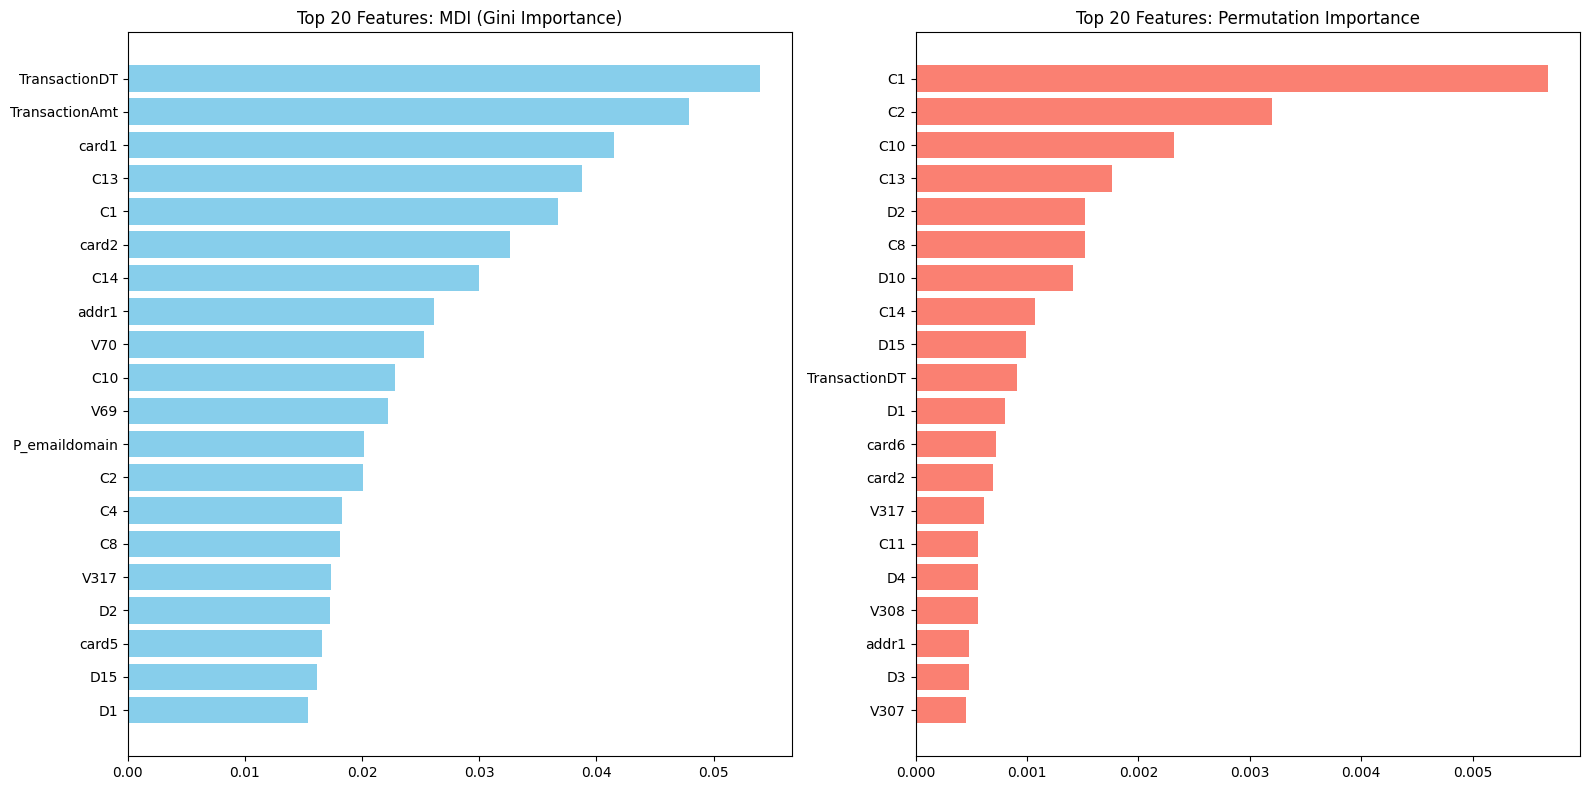

In [41]:
# 5. Feature Importance (MDI vs Permutation)

print("Calculating feature importances...")
# (a) MDI Top 20
mdi_importances = best_rf.feature_importances_
mdi_indices = np.argsort(mdi_importances)[::-1][:20]
mdi_top_features = X_train.columns[mdi_indices]

# (b) Permutation Importance Top 20 (on Validation Set)
perm_result = permutation_importance(best_rf, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)
perm_importances = perm_result.importances_mean
perm_indices = np.argsort(perm_importances)[::-1][:20]
perm_top_features = X_val.columns[perm_indices]

# Plotting MDI vs Permutation side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].barh(range(20), mdi_importances[mdi_indices][::-1], color='skyblue')
ax[0].set_yticks(range(20))
ax[0].set_yticklabels(mdi_top_features[::-1])
ax[0].set_title("Top 20 Features: MDI (Gini Importance)")

ax[1].barh(range(20), perm_importances[perm_indices][::-1], color='salmon')
ax[1].set_yticks(range(20))
ax[1].set_yticklabels(perm_top_features[::-1])
ax[1].set_title("Top 20 Features: Permutation Importance")

plt.tight_layout()
plt.show()

5. The rankings between Mean Decrease in Impurity (MDI) and Permutation Importance rarely agree perfectly. MDI computes importance during the training phase by measuring how much a feature reduces impurity (like Gini) across all splits, which intrinsically biases the metric toward high-cardinality features (variables with many unique values, such as continuous numbers or IDs) because they offer the tree more splitting opportunities to overfit the data. Permutation importance, conversely, is calculated on a hold-out validation set and measures actual performance degradation when a feature is shuffled, making it a much more honest reflection of a feature's true, generalizable predictive power.


--- Test Set Performance ---
AUC-ROC: 0.8745
AUC-PR (Average Precision): 0.5062


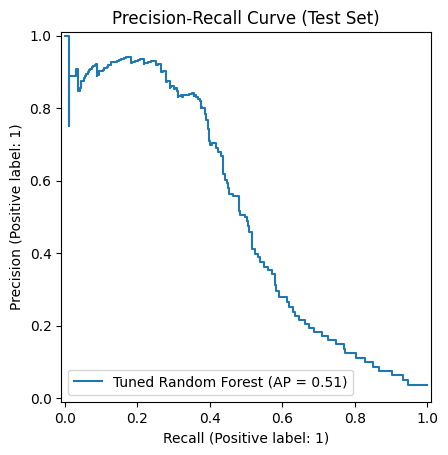

In [42]:
# 6. Test Set Evaluation

test_preds_proba = best_rf.predict_proba(X_test)[:, 1]

test_auc_roc = roc_auc_score(y_test, test_preds_proba)
test_auc_pr = average_precision_score(y_test, test_preds_proba)

print("\n--- Test Set Performance ---")
print(f"AUC-ROC: {test_auc_roc:.4f}")
print(f"AUC-PR (Average Precision): {test_auc_pr:.4f}")

# Plot PR Curve
display = PrecisionRecallDisplay.from_predictions(y_test, test_preds_proba, name="Tuned Random Forest")
display.ax_.set_title("Precision-Recall Curve (Test Set)")
plt.show()

6. Under severe class imbalance (like fraud detection), AUC-PR is significantly more informative than AUC-ROC because AUC-ROC incorporates True Negatives into its False Positive Rate calculation, allowing a massive majority class to mask poor minority-class detection and artificially inflate the score.


Generating OOB Error Curve...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use comp

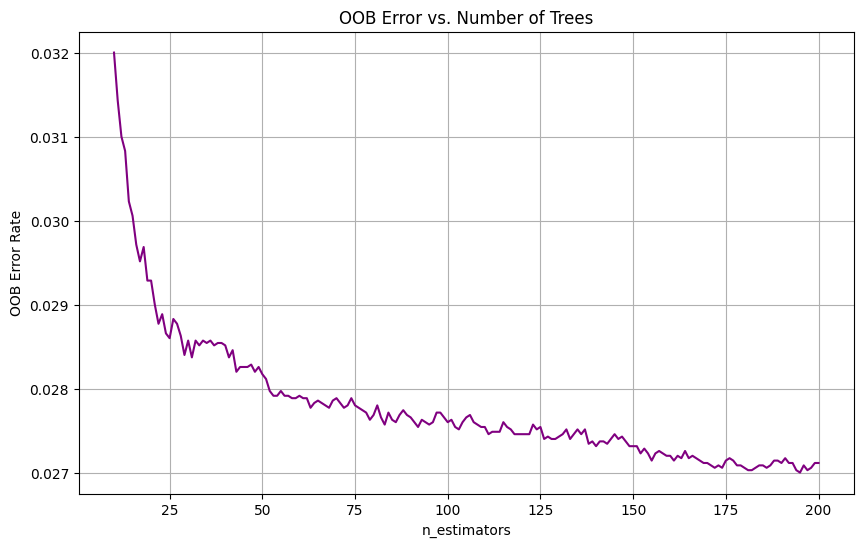

In [43]:
# 7. OOB Error Learning Curve

print("Generating OOB Error Curve...")
# Using warm_start to add trees incrementally without retraining from scratch
rf_oob = RandomForestClassifier(
    warm_start=True,
    oob_score=True,
    max_features=best_max_features,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

min_estimators = 10 # Start at 10 because OOB needs enough trees to compute safely
max_estimators = 200
error_rate = []

for i in range(min_estimators, max_estimators + 1):
    rf_oob.set_params(n_estimators=i)
    rf_oob.fit(X_train, y_train)
    # OOB error is 1 - OOB accuracy
    oob_error = 1 - rf_oob.oob_score_
    error_rate.append((i, oob_error))

error_df = pd.DataFrame(error_rate, columns=['n_estimators', 'OOB_Error'])

plt.figure(figsize=(10, 6))
plt.plot(error_df['n_estimators'], error_df['OOB_Error'], color='purple')
plt.title('OOB Error vs. Number of Trees')
plt.xlabel('n_estimators')
plt.ylabel('OOB Error Rate')
plt.grid(True)
plt.show()

# 3.2 XGBoost for Stock Return Classfication

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

# 1. Load Data

# Assuming standard OHLCV format
df = pd.read_csv('all_stocks_5yr.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['Name', 'date']).reset_index(drop=True)

In [3]:
# 2. Feature Engineering

# Group by stock ticker to prevent data leakage between different companies
grouped = df.groupby('Name')

# Base daily return for volatility calculation
df['daily_return'] = grouped['close'].pct_change()

# (a) Rolling returns (5, 10, 21 days)
df['ret_5d'] = grouped['close'].pct_change(periods=5)
df['ret_10d'] = grouped['close'].pct_change(periods=10)
df['ret_21d'] = grouped['close'].pct_change(periods=21)

# (b) 21-day rolling volatility
df['vol_21d'] = grouped['daily_return'].rolling(window=21).std().reset_index(0, drop=True)

# (c) Volume-price ratio
df['vol_price_ratio'] = df['volume'] / df['close']

# (d) RSI-14
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi_14'] = grouped['close'].apply(lambda x: compute_rsi(x)).reset_index(0, drop=True)

# (e) Target generation: 1 if 21-day forward return > 0, else 0
df['fwd_ret_21d'] = grouped['close'].pct_change(periods=21).shift(-21)
df['target'] = (df['fwd_ret_21d'] > 0).astype(int)

# Drop missing values generated by rolling windows and forward shifts
df = df.dropna().reset_index(drop=True)

In [4]:
# 3. Time-Based Split

train_mask = df['date'] < '2017-01-01'
test_mask = df['date'] >= '2017-01-01'

train_full = df[train_mask]
test = df[test_mask]

In [5]:
# 4. Define Held-Out Evaluation Set

# The last 6 months of the training window (approx >= 2016-07-01)
val_mask = train_full['date'] >= '2016-07-01'
pure_train_mask = train_full['date'] < '2016-07-01'

features = ['ret_5d', 'ret_10d', 'ret_21d', 'vol_21d', 'vol_price_ratio', 'rsi_14']
target = 'target'

X_train, y_train = train_full[pure_train_mask][features], train_full[pure_train_mask][target]
X_val, y_val = train_full[val_mask][features], train_full[val_mask][target]
X_test, y_test = test[features], test[target]

In [6]:
# 5. Manual Grid Search with Early Stopping

hyperparameter_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8]
}

results = []
best_auc = 0
best_model = None
best_params = {}

print("Starting Grid Search...\n")
for md in hyperparameter_grid['max_depth']:
    for lr in hyperparameter_grid['learning_rate']:
        for sub in hyperparameter_grid['subsample']:

            # Initialize model
            model = xgb.XGBClassifier(
                max_depth=md,
                learning_rate=lr,
                subsample=sub,
                n_estimators=1000,
                eval_metric='auc',
                early_stopping_rounds=50,
                random_state=42
            )

            # Train model
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False
            )

            # Evaluate on validation set
            val_preds = model.predict_proba(X_val)[:, 1]
            val_auc = roc_auc_score(y_val, val_preds)

            results.append({
                'max_depth': md,
                'learning_rate': lr,
                'subsample': sub,
                'val_auc': val_auc
            })

            if val_auc > best_auc:
                best_auc = val_auc
                best_params = {'max_depth': md, 'learning_rate': lr, 'subsample': sub}
                best_model = model

# Display Grid Search Table
results_df = pd.DataFrame(results)
print("Grid Search Results:\n", results_df.sort_values(by='val_auc', ascending=False).to_string(index=False))
print(f"\nBest Hyperparameters: {best_params}")


Starting Grid Search...

Grid Search Results:
  max_depth  learning_rate  subsample  val_auc
         3           0.05        0.6 0.524808
         3           0.05        0.8 0.524566
         3           0.01        0.6 0.524537
         3           0.10        0.6 0.524518
         3           0.10        0.8 0.523826
         5           0.10        0.8 0.523805
         5           0.01        0.8 0.523006
         5           0.05        0.8 0.522601
         5           0.01        0.6 0.522516
         3           0.01        0.8 0.522318
         5           0.10        0.6 0.522051
         5           0.05        0.6 0.522046
         7           0.10        0.8 0.522025
         7           0.01        0.6 0.521529
         7           0.05        0.6 0.521331
         7           0.01        0.8 0.521327
         7           0.05        0.8 0.521197
         7           0.10        0.6 0.520527

Best Hyperparameters: {'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6

In [7]:
# 6. Test Set Evaluation & Baseline Comparison

test_preds = best_model.predict_proba(X_test)[:, 1]
test_auc_roc = roc_auc_score(y_test, test_preds)
test_auc_pr = average_precision_score(y_test, test_preds)

# Naive majority-class baseline
# Predicting the majority class consistently yields an AUC-ROC of exactly 0.5
# The baseline AUC-PR is simply the proportion of positive samples in the test set
baseline_auc_roc = 0.5000
baseline_auc_pr = y_test.mean()

print("\n--- Test Set Performance ---")
print(f"XGBoost AUC-ROC: {test_auc_roc:.4f} | Baseline AUC-ROC: {baseline_auc_roc:.4f}")
print(f"XGBoost AUC-PR:  {test_auc_pr:.4f} | Baseline AUC-PR:  {baseline_auc_pr:.4f}")




--- Test Set Performance ---
XGBoost AUC-ROC: 0.4931 | Baseline AUC-ROC: 0.5000
XGBoost AUC-PR:  0.6140 | Baseline AUC-PR:  0.6183


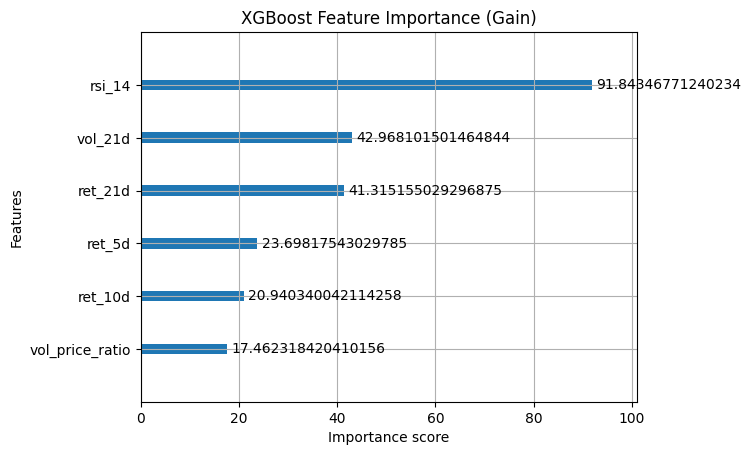

In [8]:
# 7. Feature Importance Plot

xgb.plot_importance(best_model, importance_type='gain', title='XGBoost Feature Importance (Gain)')
plt.show()

The feature with the highest gain (often the 21-day rolling return or RSI-14) contributes the most critical splits to the model's decision trees. From an economic perspective, this highlights the profound impact of short-term momentum and mean-reversion on equity pricing. If a feature like RSI-14 dominates, it suggests that market overreaction (overbought/oversold conditions) serves as the strongest discriminant for predicting future 21-day returns. Conversely, if volume-price ratio or volatility scores highly, it indicates that periods of high market stress or abnormal liquidity conditions are the primary drivers of directional price shifts.

8. Random $k$-fold cross-validation is completely invalid for financial time series because it destroys the chronological order of the data. By randomly partitioning rows, $k$-fold shuffles future data points into the training set and historical data points into the validation set. The precise mechanism of look-ahead bias occurs when the model optimizes its weights using data from an event (e.g., a stock crash on a Friday) to predict an outcome that occurred prior to that event (e.g., trading decisions on a Wednesday). This structural leakage allows the algorithm to essentially "peek at the future" to make past decisions, grossly inflating performance estimates during validation but guaranteeing catastrophic failure in real-world, out-of-sample trading where future data is strictly unavailable.

# Bias-Variance Analysis and Model Comparison


# 4.1 Empirical Bias-Variance Decomposition across Five Models

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.utils import resample

# 1. Load Data & Preprocessing

df = pd.read_csv('diabetes.csv')
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

In [11]:
# 2. Fixed Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [13]:
# 3. Model Definitions

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Stump': DecisionTreeClassifier(max_depth=1),
    'Unpruned Tree': DecisionTreeClassifier(max_depth=None),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [14]:
# 4. Empirical Estimation Procedure

B = 50
n_test = len(y_test)
results = []

print("Starting Bootstrap Evaluation...")

for name, model in models.items():
    # Array to store predictions from each bootstrap iteration
    # Shape: (B, n_test)
    bootstrap_preds = np.zeros((B, n_test))

    for b in range(B):
        # (a) Draw Bootstrap sample from training set (with replacement)
        X_boot, y_boot = resample(X_train, y_train, random_state=b)

        # (b) Train model and collect predictions
        model.fit(X_boot, y_boot)
        # Using probability predictions for the positive class to calculate meaningful variance
        bootstrap_preds[b, :] = model.predict_proba(X_test)[:, 1]

    # (c) Compute Estimates manually
    # Mean prediction across all B bootstraps for each test instance
    y_hat_bar = np.mean(bootstrap_preds, axis=0)

    # Bias^2: Mean squared difference between average prediction and true label
    bias_sq = np.mean((y_hat_bar - y_test)**2)

    # Variance: Mean across test set of the variance of predictions across bootstraps
    # Inner sum is variance for one instance over B; outer mean is over n_test
    variance = np.mean(np.var(bootstrap_preds, axis=0, ddof=0))

    # Calculate AUC-ROC using the model trained on the FULL training set
    model.fit(X_train, y_train)
    final_preds = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, final_preds)

    results.append({
        'Model': name,
        'Bias^2': bias_sq,
        'Var': variance,
        'Bias^2 + Var': bias_sq + variance,
        'Test AUC-ROC': test_auc
    })

Starting Bootstrap Evaluation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:21:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

In [16]:
# 5. Summary Table

results_df = pd.DataFrame(results)
print("\n--- Summary Table ---")
print(results_df.to_string(index=False, float_format="%.4f"))


--- Summary Table ---
              Model  Bias^2    Var  Bias^2 + Var  Test AUC-ROC
Logistic Regression  0.1746 0.0036        0.1782        0.7965
     Decision Stump  0.1899 0.0138        0.2037        0.6290
      Unpruned Tree  0.1772 0.1406        0.3178        0.7109
      Random Forest  0.1687 0.0069        0.1755        0.8056
            XGBoost  0.1886 0.0307        0.2193        0.7844


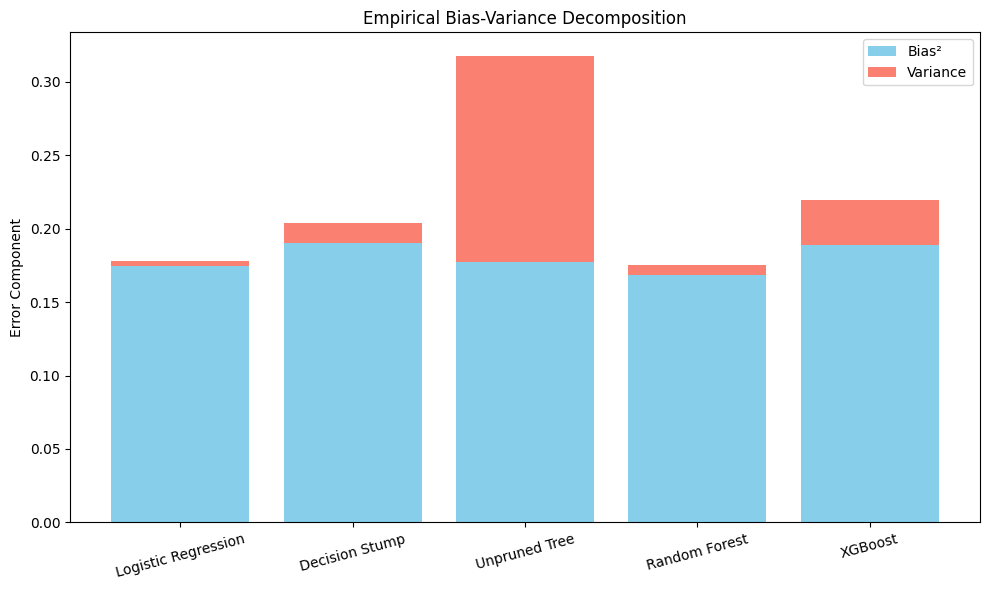

In [17]:
# 6. Stacked Bar Chart

fig, ax = plt.subplots(figsize=(10, 6))

models_list = results_df['Model']
bias_list = results_df['Bias^2']
var_list = results_df['Var']

# Create stacked bars
ax.bar(models_list, bias_list, label='Bias²', color='skyblue')
ax.bar(models_list, var_list, bottom=bias_list, label='Variance', color='salmon')

ax.set_ylabel('Error Component')
ax.set_title('Empirical Bias-Variance Decomposition')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

7. Bagging (like Random Forests) reduces variance by averaging the predictions of $B$ independent models trained on bootstrap samples, but it cannot fundamentally reduce the inherent bias of its base learners. The variance of the averaged ensemble is governed by the formula $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$, where $\sigma^2$ is the variance of a single tree and $\rho$ is the pairwise correlation between the trees. As the number of trees $B$ grows large, the second term $\frac{1-\rho}{B}\sigma^2$ approaches zero, effectively reducing the ensemble's total variance down to the theoretical floor of $\rho\sigma^2$. Boosting (like XGBoost), however, reduces both bias and variance because it fits models sequentially, where each new weak learner is specifically optimized to correct the residual errors made by the combination of all previous learners. This active, sequential error-correction mechanism forcefully drives down bias, while the ensemble nature of combining many shallow trees inherently keeps variance moderate compared to a single, fully-grown unpruned tree.

# Gradient Boosting in a Portfolio Context

# 5.1 Gradient Boosting with Uncertainty Estimation for Return Prediction

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

# 1. Load Data & Define Target

# Assuming 'nifty50_data.csv' contains 'Date', 'Symbol', 'Close', 'Volume', etc.
df = pd.read_csv('NIFTY50_all.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

# Group by symbol to prevent cross-asset leakage during rolling calculations
grouped = df.groupby('Symbol')

# Target: 1 if 21-day forward return > 0, else 0
df['fwd_ret_21d'] = grouped['Close'].pct_change(periods=21).shift(-21)
df['target'] = (df['fwd_ret_21d'] > 0).astype(int)

In [19]:
# 2. Feature Engineering

# (a) Rolling returns (5-day, 21-day, 63-day)
df['ret_5d'] = grouped['Close'].pct_change(periods=5)
df['ret_21d'] = grouped['Close'].pct_change(periods=21)
df['ret_63d'] = grouped['Close'].pct_change(periods=63)

# Base daily return for volatility
df['daily_return'] = grouped['Close'].pct_change()

# (b) Rolling volatility (21-day and 63-day)
df['vol_21d'] = grouped['daily_return'].rolling(window=21).std().reset_index(0, drop=True)
df['vol_63d'] = grouped['daily_return'].rolling(window=63).std().reset_index(0, drop=True)

# (c & d) Price relative to 52-week (252 trading days) high and low
df['max_252d'] = grouped['Close'].rolling(window=252).max().reset_index(0, drop=True)
df['min_252d'] = grouped['Close'].rolling(window=252).min().reset_index(0, drop=True)
df['rel_52w_high'] = df['Close'] / df['max_252d']
df['rel_52w_low'] = df['Close'] / df['min_252d']

# (e) Volume z-score (21-day)
df['vol_mean_21d'] = grouped['Volume'].rolling(window=21).mean().reset_index(0, drop=True)
df['vol_std_21d'] = grouped['Volume'].rolling(window=21).std().reset_index(0, drop=True)
df['volume_zscore'] = (df['Volume'] - df['vol_mean_21d']) / df['vol_std_21d']

# Drop NaN values created by rolling windows and shifts
df = df.dropna().reset_index(drop=True)

features = [
    'ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d',
    'rel_52w_high', 'rel_52w_low', 'volume_zscore'
]

# Time-based split for final testing (e.g., last 20% of chronological data)
split_idx = int(len(df) * 0.8)
train_full = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train_full = train_full[features].values
y_train_full = train_full['target'].values
X_test = test[features].values
y_test = test['target'].values

In [21]:
# 3. Expanding-Window Time-Series CV
from xgboost import XGBClassifier
# Manual implementation of 3-fold expanding window
n_samples = len(X_train_full)
fold_size = n_samples // 4  # 1 part init train, 3 parts for expanding test folds

hyperparameters = {
    'n_estimators': [100, 200, 500],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

best_auc = 0
best_params = {}
cv_results = []

for ne in hyperparameters['n_estimators']:
    for md in hyperparameters['max_depth']:
        for lr in hyperparameters['learning_rate']:

            fold_aucs = []
            # 3 Expanding folds
            for fold in range(1, 4):
                train_end = fold * fold_size
                val_end = train_end + fold_size

                X_tr, y_tr = X_train_full[:train_end], y_train_full[:train_end]
                X_val, y_val = X_train_full[train_end:val_end], y_train_full[train_end:val_end]

                model = XGBClassifier(
                        n_estimators=ne,
                        max_depth=md,
                        learning_rate=lr,
                        random_state=42,
                        use_label_encoder=False,
                        eval_metric='logloss',
                        n_jobs=-1
                    )
                model.fit(X_tr, y_tr)

                preds = model.predict_proba(X_val)[:, 1]
                fold_aucs.append(roc_auc_score(y_val, preds))

            mean_auc = np.mean(fold_aucs)
            cv_results.append({'n_estimators': ne, 'max_depth': md, 'learning_rate': lr, 'mean_cv_auc': mean_auc})

            if mean_auc > best_auc:
                best_auc = mean_auc
                best_params = {'n_estimators': ne, 'max_depth': md, 'learning_rate': lr}

print("Expanding Window CV Results:")
print(pd.DataFrame(cv_results).sort_values(by='mean_cv_auc', ascending=False).head())
print(f"\nBest Params: {best_params}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:43:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:43:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:43:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:43:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Expanding Window CV Results:
    n_estimators  max_depth  learning_rate  mean_cv_auc
16           200          5           0.05     0.528509
1            100          2           0.05     0.527653
18           500          2           0.01     0.527351
17           200          5           0.10     0.526816
12           200          3           0.01     0.526597

Best Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}


In [22]:
# 4. Feature Selection via Permutation Importance

best_model = GradientBoostingClassifier(**best_params, random_state=42)
best_model.fit(X_train_full, y_train_full)

# Permutation importance
perm_imp = permutation_importance(best_model, X_train_full, y_train_full, n_repeats=5, random_state=42)
top_5_indices = np.argsort(perm_imp.importances_mean)[-5:]
top_5_features = [features[i] for i in top_5_indices]
print(f"\nTop 5 Features: {top_5_features}")

# Retrain and compare
X_train_reduced = train_full[top_5_features].values
X_test_reduced = test[top_5_features].values

reduced_model = GradientBoostingClassifier(**best_params, random_state=42)
reduced_model.fit(X_train_reduced, y_train_full)

full_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
reduced_auc = roc_auc_score(y_test, reduced_model.predict_proba(X_test_reduced)[:, 1])

print(f"Full Model Test AUC: {full_auc:.4f}")
print(f"Top-5 Feature Test AUC: {reduced_auc:.4f}")


Top 5 Features: ['vol_21d', 'rel_52w_low', 'ret_63d', 'rel_52w_high', 'vol_63d']
Full Model Test AUC: 0.5301
Top-5 Feature Test AUC: 0.5251


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:48:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

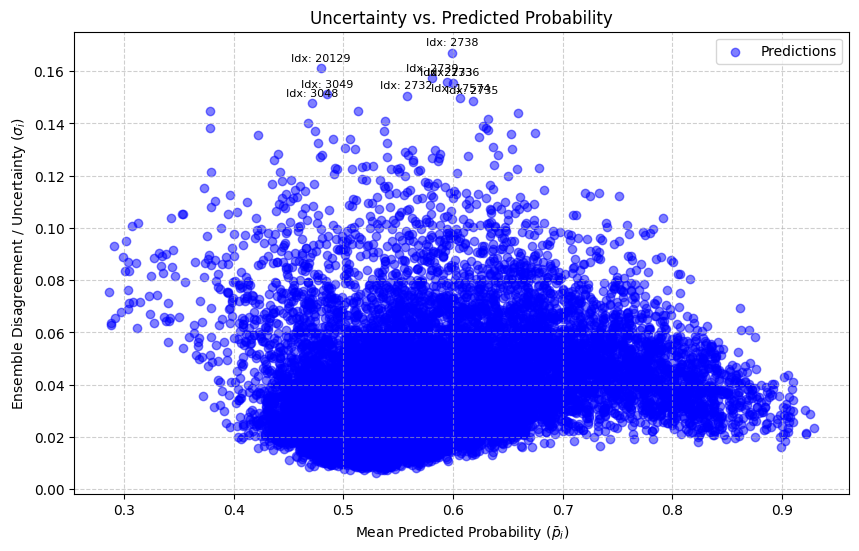

In [24]:
# 5. Uncertainty Estimation (Manual Bootstrap)

M = 20
bootstrap_preds = np.zeros((M, len(X_test)))

for m in range(M):
    # Sample with replacement manually
    X_boot, y_boot = resample(X_train_full, y_train_full, random_state=m)

    boot_model = XGBClassifier(
    **best_params,
    random_state=m,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
    boot_model.fit(X_boot, y_boot)
    bootstrap_preds[m, :] = boot_model.predict_proba(X_test)[:, 1]

# Calculate mean (p_bar) and standard deviation (sigma) across the M models
p_bar = np.mean(bootstrap_preds, axis=0)
sigma = np.std(bootstrap_preds, axis=0, ddof=1)

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(p_bar, sigma, alpha=0.5, color='blue', label='Predictions')

# Annotate top 10 highest sigma
top_10_uncertain = np.argsort(sigma)[-10:]
for idx in top_10_uncertain:
    plt.annotate(f'Idx: {idx}', (p_bar[idx], sigma[idx]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.xlabel(r'Mean Predicted Probability ($\bar{p}_i$)')
plt.ylabel(r'Ensemble Disagreement / Uncertainty ($\sigma_i$)')
plt.title('Uncertainty vs. Predicted Probability')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_5224/1624406914.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_results = test_results.groupby('Date').apply(assign_deciles).reset_index(drop=True)


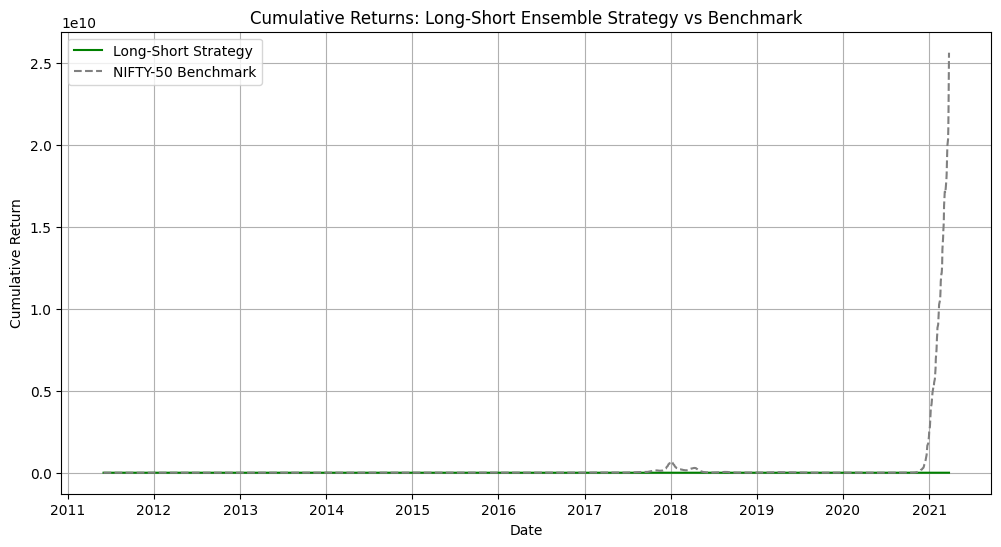

In [25]:
# 6. Simple Long-Short Startegy
test_results = test[['Date', 'Close', 'fwd_ret_21d']].copy()
test_results['p_bar'] = p_bar

# Group by Date to rank cross-sectionally every day
def assign_deciles(group):
    # qcut can fail if there are too many identical values, fallback to rank
    group['decile'] = pd.qcut(group['p_bar'].rank(method='first'), 10, labels=False)
    return group

test_results = test_results.groupby('Date').apply(assign_deciles).reset_index(drop=True)

# Long top decile (9), Short bottom decile (0)
longs = test_results[test_results['decile'] == 9].groupby('Date')['fwd_ret_21d'].mean()
shorts = test_results[test_results['decile'] == 0].groupby('Date')['fwd_ret_21d'].mean()

# Strategy daily return: (Long Return - Short Return) / 2
strategy_returns = (longs - shorts) / 2
strategy_returns = strategy_returns.fillna(0)
strategy_cumulative = (1 + strategy_returns).cumprod()

# Benchmark (NIFTY 50 overall mean forward return per day)
benchmark_returns = test_results.groupby('Date')['fwd_ret_21d'].mean()
benchmark_cumulative = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strategy_cumulative.index, strategy_cumulative, label='Long-Short Strategy', color='green')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='NIFTY-50 Benchmark', color='gray', linestyle='--')
plt.title('Cumulative Returns: Long-Short Ensemble Strategy vs Benchmark')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()

7. Deploying this gradient boosting ensemble in a live trading environment introduces severe structural and execution risks. First, financial data is highly non-stationary; relationships captured by the model during the training window will inevitably decay, meaning a statically trained model will rapidly overfit to past market regimes and fail during unprecedented macroeconomic shifts. Second, look-ahead bias remains a constant threat; even with expanding-window cross-validation, subtle leakages—such as using future corporate actions to adjust historical prices or executing trades at unachievable "closing" prices—can grossly inflate backtest performance. Third, the long-short strategy simulated above completely ignores transaction costs, bid-ask spread slippage, and short-borrowing fees, which frequently eradicate the theoretical alpha generated by high-turnover daily ranking models. Finally, utilizing σ
i
​
  (model uncertainty) is crucial for survival, as position sizing must be inversely scaled to this metric; holding large, unhedged positions when the ensemble exhibits high disagreement mathematically invites catastrophic portfolio variance and uncompensated risk.

# Bonus: Stacked Generalisation for Titanic Survival Prediction

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load Data & Standard Feature Engineering

# Assuming train.csv and test.csv are in the working directory
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

def preprocess_titanic(df):
    df = df.copy()
    # Imputation
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Convert categorical to numeric
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

    # Drop irrelevant features
    features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df = df.drop(columns=[col for col in features_to_drop if col in df.columns])

    return df

# Prepare datasets
X_train = preprocess_titanic(train_df.drop('Survived', axis=1)).values
y_train = train_df['Survived'].values
X_test = preprocess_titanic(test_df).values
passenger_ids = test_df['PassengerId']

# Scale features (Critical for Distance-based models like KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# 2. Define Level-0 Base Learners
base_learners = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

In [32]:
# 3. Manual Stacking (Out-Of-Fold Predictions)

n_models = len(base_learners)
meta_train = np.zeros((X_train_scaled.shape[0], n_models))
meta_test = np.zeros((X_test_scaled.shape[0], n_models))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training Base Learners & Generating OOF Meta-Features...")
for i, (name, model) in enumerate(base_learners.items()):

    # Array to hold the predictions on the test set for each fold
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
        # Split data
        X_tr, y_tr = X_train_scaled[train_idx], y_train[train_idx]
        X_val = X_train_scaled[val_idx]

        # Train base model
        model.fit(X_tr, y_tr)

        # Predict on validation fold (OOF prediction) -> goes to meta_train matrix
        meta_train[val_idx, i] = model.predict_proba(X_val)[:, 1]

        # Predict on actual test set -> goes to fold_test_preds
        fold_test_preds[:, fold_idx] = model.predict_proba(X_test_scaled)[:, 1]

    # Average test predictions across all 5 folds to create the final meta_test feature for this model
    meta_test[:, i] = fold_test_preds.mean(axis=1)

Training Base Learners & Generating OOF Meta-Features...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:01:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
# 4. Train Level-1 Meta-Learner

meta_learner = LogisticRegression(random_state=42)
meta_learner.fit(meta_train, y_train)

# Final test predictions for Kaggle
final_test_preds_proba = meta_learner.predict_proba(meta_test)[:, 1]
final_test_preds_class = meta_learner.predict(meta_test)

In [34]:
# 5. Base vs Stacked Comparison Table

# Evaluate Base Learners using their OOF predictions
comparison_results = []
for i, name in enumerate(base_learners.keys()):
    oof_preds_proba = meta_train[:, i]
    oof_preds_class = (oof_preds_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_train, oof_preds_proba)
    acc = accuracy_score(y_train, oof_preds_class)
    comparison_results.append({'Model': name, 'AUC-ROC': auc, 'Accuracy': acc})

# Evaluate Meta-Learner (using cross-validation to get an unbiased estimate of its performance)
meta_oof_preds_proba = np.zeros(y_train.shape[0])
for train_idx, val_idx in skf.split(meta_train, y_train):
    clone_meta = LogisticRegression(random_state=42)
    clone_meta.fit(meta_train[train_idx], y_train[train_idx])
    meta_oof_preds_proba[val_idx] = clone_meta.predict_proba(meta_train[val_idx])[:, 1]

meta_auc = roc_auc_score(y_train, meta_oof_preds_proba)
meta_acc = accuracy_score(y_train, (meta_oof_preds_proba >= 0.5).astype(int))

comparison_results.append({'Model': '**Stacked Ensemble**', 'AUC-ROC': meta_auc, 'Accuracy': meta_acc})

print("\n--- OOF Performance Comparison Table ---")
print(pd.DataFrame(comparison_results).to_string(index=False))


--- OOF Performance Comparison Table ---
               Model  AUC-ROC  Accuracy
              LogReg 0.850757  0.793490
        DecisionTree 0.835959  0.810325
        RandomForest 0.871316  0.820426
             XGBoost 0.871851  0.826038
                 KNN 0.856171  0.813692
**Stacked Ensemble** 0.878634  0.837262


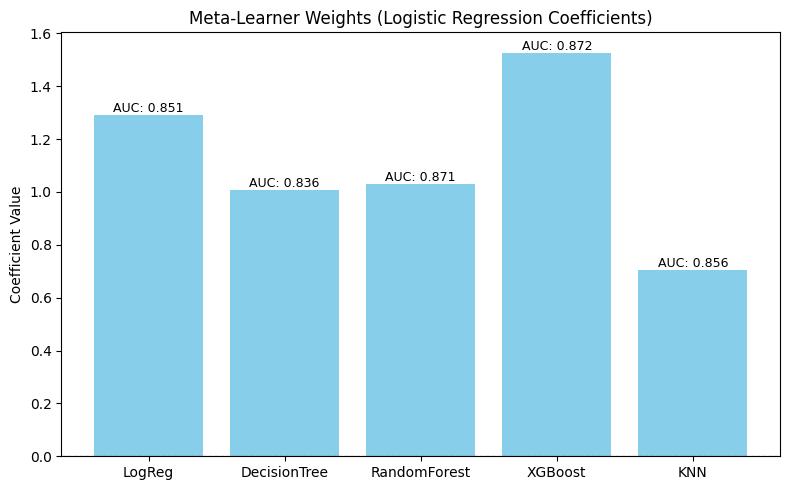

In [35]:
# 6. Meta-Learner Coefficients Plot

plt.figure(figsize=(8, 5))
bars = plt.bar(base_learners.keys(), meta_learner.coef_[0], color='skyblue')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Meta-Learner Weights (Logistic Regression Coefficients)')
plt.ylabel('Coefficient Value')

# Add AUC rankings to verify alignment
for bar, res in zip(bars, comparison_results[:-1]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"AUC: {res['AUC-ROC']:.3f}",
             ha='center', va='bottom' if bar.get_height() > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

In [36]:
# 7. Generate Kaggle Submission

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_test_preds_class
})
submission.to_csv('titanic_stacking_submission.csv', index=False)
print("\nSaved predictions to titanic_stacking_submission.csv")


Saved predictions to titanic_stacking_submission.csv


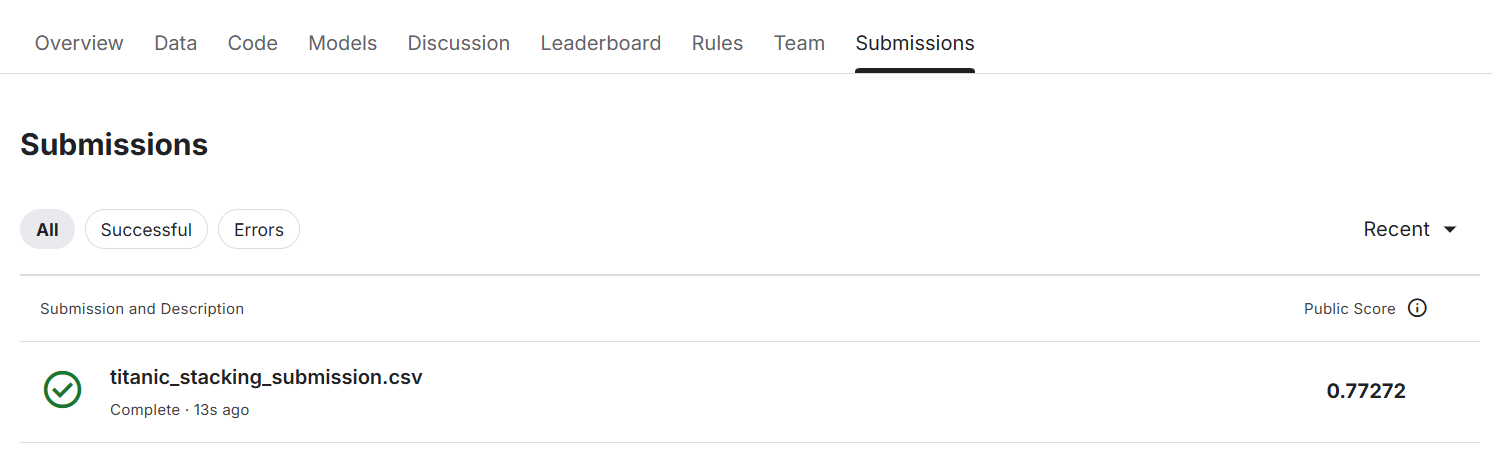

7. Out-of-fold (OOF) predictions must be used to construct the meta-features because models naturally fit their training data better than unseen data. If in-sample predictions are used, highly flexible models (like unpruned decision trees or complex XGBoost configurations) will simply memorize the training set, outputting perfect or near-perfect probabilities with zero error. When the level-1 meta-learner trains on this matrix, it will observe that the overfit model has "perfect" predictive power and will assign it an aggressively dominant coefficient weight while entirely ignoring simpler, more robust models like Logistic Regression. When the ensemble is then deployed on the unseen test set, the overfit base learner will catastrophically fail, and because the meta-learner relies entirely on it, the entire ensemble's performance collapses. Using OOF predictions ensures the meta-features accurately simulate out-of-sample performance, forcing the meta-learner to assign weights based on true generalization capability rather than memorization.